In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report


tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [14]:

X_train = np.load('../data/processed/X_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (2425, 150)
y_train shape: (2425,)


In [15]:
VOCAB_SIZE = 10000
MAX_LEN = 200 

EMBEDDING_SIM = 64 # mỗi từ được biểu diễn bằng vecto 64 chiều 
HIDDEN_DIM = 64 # Số lượng nouron trong lớp LSTM 
EPOCHS = 10 # số vòng lặp huấn luyện tối đa 
BATCH_SIZE = 32 # số lượng mẫu dữ liệu nạp vào mỗi lần cập nhật

In [16]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def derivative(f, z, eps=0.000001):
    return (f(z + eps) - f(z - eps))/(2 * eps)

In [17]:
def build_model():
    model = Sequential()
    model.add(Embedding(input_dim = VOCAB_SIZE+1 , 
                        output_dim = EMBEDDING_SIM ,
                        input_length = MAX_LEN))
    model.add(Bidirectional(LSTM(HIDDEN_DIM , return_sequences = True)))
    model.add(GlobalAveragePooling1D())
    model.add(Dropout(0.5))
    model.add(Dense(32 , activation = "relu"))
    model.add(Dense(1 , activation = "sigmoid" ))
    model.compile( loss = "binary_crossentropy",
                  optimizer = "adam" ,
                  metrics = ["accuracy"])
    return model
model = build_model()
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
checkpoint_path = "../saved_models/best_model.keras" # Hoặc .h5

callbacks = [
    EarlyStopping(patience=3, monitor='val_loss', restore_best_weights=True),
    ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_loss')
]

In [19]:
history = model.fit(X_train, y_train,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(X_test, y_test),
                    callbacks=callbacks,
                    verbose=1)

Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.8128 - loss: nan - val_accuracy: 0.8418 - val_loss: nan
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.8202 - loss: nan - val_accuracy: 0.8418 - val_loss: nan
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8202 - loss: nan - val_accuracy: 0.8418 - val_loss: nan
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.8202 - loss: nan - val_accuracy: 0.8418 - val_loss: nan


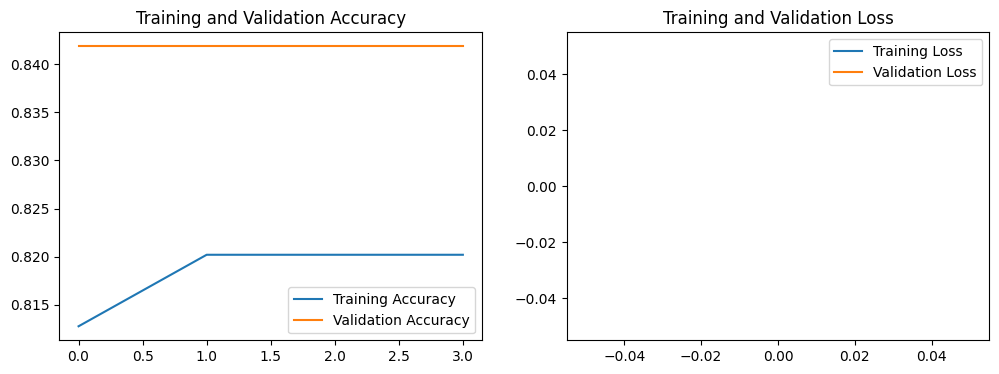

In [ ]:
def plot_history(history):
   acc = history.history['accuracy']
   val_acc = history.history['val_accuracy']
   loss = history.history['loss']
   val_loss = history.history['val_loss']
   epochs_range = range(len(acc))

   plt.figure(figsize=(12, 4))
    
   plt.subplot(1, 2, 1)
   plt.plot(epochs_range, acc, label='Training Accuracy')
   plt.plot(epochs_range, val_acc, label='Validation Accuracy')
   plt.legend(loc='lower right')
   plt.title('Training and Validation Accuracy')

   plt.subplot(1, 2, 2)
   plt.plot(epochs_range, loss, label='Training Loss')
   plt.plot(epochs_range, val_loss, label='Validation Loss')
   plt.legend(loc='upper right')
   plt.title('Training and Validation Loss')
   plt.show()

plot_history(history)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Classification Report:

              precision    recall  f1-score   support

         Ham       0.85      1.00      0.92       515
        Spam       0.00      0.00      0.00        92

    accuracy                           0.85       607
   macro avg       0.42      0.50      0.46       607
weighted avg       0.72      0.85      0.78       607



c:\Users\MY-PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MY-PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MY-PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

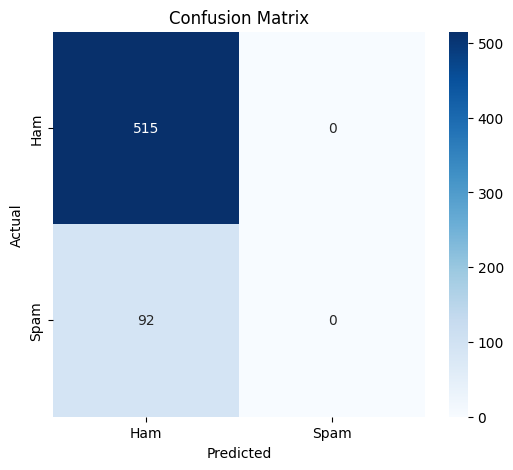

In [ ]:
y_pred_prob = model.predict(X_test)

y_pred_prob = np.nan_to_num(y_pred_prob, nan=0.5)  
y_pred = (y_pred_prob > 0.5).astype(int).flatten() 
y_test_clean = np.nan_to_num(y_test, nan=0).flatten()  


print("Classification Report:\n")
print(classification_report(y_test_clean, y_pred, target_names=['Ham', 'Spam']))

cm = confusion_matrix(y_test_clean, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()